# Seq2Seq Übersetzungsmodell, DPO Fine-Tuning & Evaluierung
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook kapselt das Training und die Evaluierung des Übersetzungsmodells:
1. **Phase 1: Supervised Fine-Tuning (SFT)** – Das Sequence-to-Sequence Basismodell wird auf parallelen Korpuspaaren vortrainiert.
2. **Phase 2 & 3: Direct Preference Optimization (DPO)** – Feinjustierung des Übersetzers mithilfe einer **Composite Reward-Funktion** bestehend aus:
   - **1. Stil & Einfachheits-Score ($R_{\text{style}}$):** Unser trainierter **BiLSTM Synthetic Regressor** (`bilstm_synthetic_regression.pt`), der den Zielgrad an Leichter Sprache $\lambda \in [0, 1]$ misst.
   - **2. Semantischer Erhalt ($R_{\text{sem}}$):** **SBERT / Jina Cosine Similarity**, welche die inhaltliche Übereinstimmung zwischen Quelltext $x_{\text{AS}}$ und Übersetzung $y'$ misst.
3. **Phase 4: Evaluierung auf dem unabhängigen Lebenshilfe-Datensatz** – Das trainierte Modell übersetzt den Out-of-Domain Datensatz (`data/lebenshilfe/lebenshilfe_dataset.json`) und wird bewertet.

In [14]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

Aktuelles Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


In [15]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_clean.json"
CORPUS_CSV_PATH = "data/analysis/corpus_master.csv"
SFT_MODEL_TEMP_PATH = "results/models/2_sft.pt"

MIN_SIM = 0.70
MAX_SIM = 0.98

MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
MODEL_NAME = "facebook/mbart-large-50"


## 1. Setup & Importe

In [16]:
import torch
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU")

import os
print("Aktuelles Arbeitsverzeichnis von Python:", os.getcwd())
print("Existiert der data-Ordner hier?", os.path.exists("data"))
print("Existiert der data-Ordner eine Ebene höher?", os.path.exists("../data"))

# Set seed for reproducibility
def set_seed(seed=42):
    import random
    import numpy as np
    import torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Globaler Seed auf {seed} gesetzt.")

set_seed(42)


CUDA verfügbar: False
Device Name: Keine GPU
Aktuelles Arbeitsverzeichnis von Python: /Users/fietescheel/Documents/Master Thesis
Existiert der data-Ordner hier? True
Existiert der data-Ordner eine Ebene höher? False
Globaler Seed auf 42 gesetzt.


In [17]:
import os
import json
import glob
import random
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sentence_transformers import SentenceTransformer, util

print(torch.__version__)


# Device Configuration
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Nutze Device: {DEVICE}")

2.11.0
Nutze Device: mps


## 2. Datenladen & Korpus-Vorbereitung
Wir laden alle Korpusdaten aus `../../data/corpus/final/` für das SFT & DPO Training.

In [18]:
import os
import glob

# 1. Wo sind wir gerade?
print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

# 2. Was liegt in diesem Arbeitsverzeichnis?
print("Dateien hier:", os.listdir("."))

# 3. Teste verschiedene Pfade zu 'data/corpus/final'
pfade_zum_testen = [
    "data/corpus/final",
    "data/corpus/final",
    "data/corpus/final",
    "C:/Users/fiete/git/master/data/corpus/final" # Absoluter Pfad
]

for pfad in pfade_zum_testen:
    existiert = os.path.exists(pfad)
    anzahl_dateien = len(glob.glob(os.path.join(pfad, "*.json"))) if existiert else 0
    print(f"Pfad '{pfad}': Existiert = {existiert}, JSON-Dateien = {anzahl_dateien}")

Aktuelles Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis
Dateien hier: ['research', '.DS_Store', 'run_jupyter_server.md', 'requirements.txt', 'web', '.obsidian', '__pycache__', 'docs', 'README.md', 'results', '.gitignore', 'jupyter.log', '.venv', 'scripts', 'templates', 'thesis', '.git', 'data', 'notebooks']
Pfad 'data/corpus/final': Existiert = False, JSON-Dateien = 0
Pfad 'data/corpus/final': Existiert = False, JSON-Dateien = 0
Pfad 'data/corpus/final': Existiert = False, JSON-Dateien = 0
Pfad 'C:/Users/fiete/git/master/data/corpus/final': Existiert = False, JSON-Dateien = 0


In [19]:
def load_filtered_corpus(csv_path=CORPUS_CSV_PATH, min_sim=MIN_SIM, max_sim=MAX_SIM):
    import pandas as pd
    df = pd.read_csv(csv_path)
    filtered_df = df[
        (df["semantic_similarity_8192"] >= min_sim) & 
        (df["semantic_similarity_8192"] <= max_sim)
    ]
    print(f"Gesamtpaare in CSV: {len(df)}")
    print(f"Paare nach Filterung ({min_sim} <= Sim <= {max_sim}): {len(filtered_df)}")
    
    pairs = []
    for _, row in filtered_df.iterrows():
        as_text = str(row["as_text"]).strip()
        ls_text = str(row["ls_text"]).strip()
        if as_text and ls_text:
            pairs.append({
                "source": row["source"],
                "as_text": as_text,
                "ls_text": ls_text
            })
    return pairs

all_pairs = load_filtered_corpus(min_sim=MIN_SIM, max_sim=MAX_SIM)
print(f"Gesamtzahl geladener Artikel-Paare: {len(all_pairs)}")

# Split in Train (85%), Val (15%)
set_seed(42)
random.shuffle(all_pairs)
split_idx = int(0.85 * len(all_pairs))
train_data = all_pairs[:split_idx]
val_data = all_pairs[split_idx:]
print(f"Trainingsdaten: {len(train_data)} Paare | Validierungsdaten: {len(val_data)} Paare")


Gesamtpaare in CSV: 1466
Paare nach Filterung (0.7 <= Sim <= 0.98): 1343
Gesamtzahl geladener Artikel-Paare: 1343
Globaler Seed auf 42 gesetzt.
Trainingsdaten: 1141 Paare | Validierungsdaten: 202 Paare


## 3. Phase 1: Supervised Fine-Tuning (SFT) Baseline

> **Hinweis zur Modellwahl:**
> - `google/mt5-small` (~1.2 GB, sehr schneller Download & Start)
> - `google/mt5-base` (~2.2 GB)
> - `facebook/mbart-large-50` (~2.44 GB, großes Modell mit vortrainierter deutscher Übersetzung)

In [20]:
# Optionen: "google/mt5-small", "google/mt5-base", "facebook/mbart-large-50"
# MODEL_NAME = "facebook/mbart-large-50"  # -> Zentral oben definiert
# MAX_SOURCE_LEN = 256  # -> Zentral oben definiert
# MAX_TARGET_LEN = 256  # -> Zentral oben definiert

print(f"Lade Tokenizer & Modell: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)
seq2seq_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

if "mbart" in MODEL_NAME.lower():
    tokenizer.src_lang = "de_DE"
    tokenizer.tgt_lang = "de_DE"

print("Modell & Tokenizer erfolgreich geladen!")

Lade Tokenizer & Modell: facebook/mbart-large-50...
Modell & Tokenizer erfolgreich geladen!


In [21]:
seq2seq_model.load_state_dict(torch.load(SFT_MODEL_TEMP_PATH))
print("Erfolgreich SFT-Modellgewichte von Festplatte geladen!")

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

In [23]:
state_dict = torch.load(SFT_MODEL_TEMP_PATH, map_location=DEVICE)
seq2seq_model.load_state_dict(state_dict)

# 4. Modell auf das Gerät verschieben
seq2seq_model.to(DEVICE)
print(f"Modell erfolgreich auf {DEVICE} geladen!")

Modell erfolgreich auf mps geladen!


In [9]:
class TranslationDataset(Dataset):
    def __init__(self, data, tokenizer, max_src_len=256, max_tgt_len=256):
        self.data = data
        self.tokenizer = tokenizer
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        src_text = "Übersetze in Leichte Sprache: " + item["as_text"]
        tgt_text = item["ls_text"]
        
        inputs = self.tokenizer(
            src_text, max_length=self.max_src_len, padding="max_length", truncation=True, return_tensors="pt"
        )
        labels = self.tokenizer(
            tgt_text, max_length=self.max_tgt_len, padding="max_length", truncation=True, return_tensors="pt"
        )["input_ids"]
        
        labels[labels == self.tokenizer.pad_token_id] = -100
        
        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": labels.squeeze(0),
            "raw_as": item["as_text"],
            "raw_ls": item["ls_text"]
        }

train_dataset = TranslationDataset(train_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)
val_dataset = TranslationDataset(val_data, tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
print(f"DataLoader erstellt: {len(train_loader)} Batches (Train), {len(val_loader)} Batches (Val).")

DataLoader erstellt: 286 Batches (Train), 51 Batches (Val).


Starte SFT Training mit Validation und Early Stopping...

--- Epoche 1/20 ---


SFT Training:   0%|          | 0/286 [00:00<?, ?it/s]

SFT Validation:   0%|          | 0/51 [00:00<?, ?it/s]

Epoche 1 | Train Loss: 2.9921 | Val Loss: 2.3834
-> Neues bestes Modell gespeichert.

--- Epoche 2/20 ---


SFT Training:   0%|          | 0/286 [00:00<?, ?it/s]

...

SFT Validation:   0%|          | 0/51 [00:00<?, ?it/s]

Epoche 19 | Train Loss: 0.4923 | Val Loss: 1.3209

--- Epoche 20/20 ---


SFT Training:   0%|          | 0/286 [00:00<?, ?it/s]

SFT Validation:   0%|          | 0/51 [00:00<?, ?it/s]

Epoche 20 | Train Loss: 0.4576 | Val Loss: 1.3431
Die besten SFT-Gewichte wurden erfolgreich geladen!


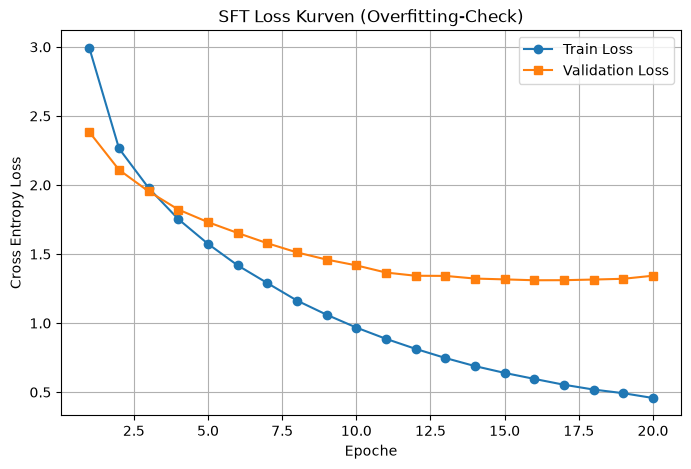

In [10]:
def train_sft_epoch(model, dataloader, optimizer, scheduler, accumulation_steps=4):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()  # Gradienten zu Beginn der Epoche nullen
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="SFT Training")):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        
        # Loss berechnen und durch die Anzahl der Akkumulationsschritte teilen
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss / accumulation_steps
        loss.backward()
        
        # Nur alle 'accumulation_steps' (4) Batches den Optimierungsschritt machen
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()  # Gradienten nach dem Schritt wieder zurücksetzen
            
        total_loss += loss.item() * accumulation_steps
        
    return total_loss / len(dataloader)

def validate_sft_epoch(model, dataloader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="SFT Validation"):
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                
            total_loss += outputs.loss.item()
            
    return total_loss / len(dataloader)

NUM_EPOCHS = 20
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": []}

optimizer = AdamW(seq2seq_model.parameters(), lr=1e-5)
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=150, 
    num_training_steps=len(train_loader) * NUM_EPOCHS
)

print("Starte SFT Training mit Validation und Early Stopping...")
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoche {epoch + 1}/{NUM_EPOCHS} ---")
    
    # Train und Val Losses berechnen
    sft_loss = train_sft_epoch(seq2seq_model, train_loader, optimizer, scheduler)
    val_loss = validate_sft_epoch(seq2seq_model, val_loader)
    
    history["train_loss"].append(sft_loss)
    history["val_loss"].append(val_loss)
    
    print(f"Epoche {epoch + 1} | Train Loss: {sft_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Early Stopping und Model Saving Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Bestes Modell zwischenspeichern
        torch.save(seq2seq_model.state_dict(), SFT_MODEL_TEMP_PATH)
        print("-> Neues bestes Modell gespeichert.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early Stopping getriggert! Keine Verbesserung des Val Loss seit {patience} Epochen.")
            # Lade beste Gewichte wieder
            seq2seq_model.load_state_dict(torch.load(SFT_MODEL_TEMP_PATH))
            break

if os.path.exists(SFT_MODEL_TEMP_PATH):
    seq2seq_model.load_state_dict(torch.load(SFT_MODEL_TEMP_PATH))
    print("Die besten SFT-Gewichte wurden erfolgreich geladen!")


# Visualisierung der SFT Loss-Kurven
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker='o', label='Train Loss')
plt.plot(range(1, len(history["val_loss"]) + 1), history["val_loss"], marker='s', label='Validation Loss')
plt.title("SFT Loss Kurven (Overfitting-Check)")
plt.xlabel("Epoche")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True)
plt.show()


## 4. Phase 4: Evaluierung auf dem unabhängigen Lebenshilfe-Datensatz
Das trainierte Modell übersetzt nun den unabhängigen Lebenshilfe-Datensatz (`data/lebenshilfe/lebenshilfe_dataset.json`). Wir berechnen die Rewards und bewerten die Qualität.

In [24]:
import json
import os
print("Aktueller Pfad im Notebook:", os.path.abspath(LH_DATASET_PATH))
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)
print("Tatsächliche Anzahl der Einträge auf der Platte:", len(data))

Aktueller Pfad im Notebook: /Users/fietescheel/Documents/Master Thesis/data/lebenshilfe/lebenshilfe_dataset_clean.json
Tatsächliche Anzahl der Einträge auf der Platte: 44


In [25]:
# 4.1 BiLSTM Regressor & Vocab laden
SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"
SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"
W_STYLE = 0.5
W_SEM = 0.5

class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

with open(SYNTHETIC_VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab_data = json.load(f)
    synthetic_stoi = vocab_data.get("stoi", vocab_data)

bilstm_model = BiLSTMRegressor(len(synthetic_stoi), embed_dim=128, hidden_dim=128)
if os.path.exists(SYNTHETIC_MODEL_PATH):
    bilstm_model.load_state_dict(torch.load(SYNTHETIC_MODEL_PATH, map_location="cpu"))
    bilstm_model.to("cpu")
    bilstm_model.eval()
    print(f"BiLSTM Synthetic Regressor erfolgreich geladen von {SYNTHETIC_MODEL_PATH}")
else:
    print(f"Warnung: {SYNTHETIC_MODEL_PATH} nicht gefunden.")

nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer"])

def predict_simplicity_score(texts):
    scores = []
    unk_idx = synthetic_stoi.get("<unk>") or synthetic_stoi.get("<UNK>") or 1
    for text in texts:
        doc = nlp(text)
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [synthetic_stoi.get(t, unk_idx) for t in tokens[:150]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

BiLSTM Synthetic Regressor erfolgreich geladen von results/models/bilstm_synthetic_regression.pt


In [26]:
# 4.2 SBERT Semantic Similarity Model laden
SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device="cpu")

def predict_semantic_similarity(source_texts, generated_texts):
    emb_src = sbert_model.encode(source_texts, convert_to_tensor=True)
    emb_gen = sbert_model.encode(generated_texts, convert_to_tensor=True)
    cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=0.5, w_sem=0.5):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts) # [0, 1]
        r_sem = predict_semantic_similarity(source_texts, generated_texts) # [-1, 1]
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=W_STYLE, w_sem=W_SEM)

Lade SBERT Modell: sentence-transformers/paraphrase-multilingual-mpnet-base-v2...


In [27]:
# 4.3 Lebenshilfe-Datensatz laden & evaluieren
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

def evaluate_on_lebenshilfe(model, tokenizer, lh_data, reward_evaluator, max_samples=49):
    model.eval()
    as_texts = [item["as_text"] for item in lh_data[:max_samples]]
    ls_ref_texts = [item["ls_text"] for item in lh_data[:max_samples]]
    
    batch_size = 16
    gen_texts = []
    for i in tqdm(range(0, len(as_texts), batch_size), desc="Übersetze Lebenshilfe Datensatz"):
        batch_src = as_texts[i:i+batch_size]
        prompts = ["Übersetze in Leichte Sprache: " + t for t in batch_src]
        inputs = tokenizer(prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                repetition_penalty=2.5,
                no_repeat_ngram_size=3,
                early_stopping=True
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend(decoded)
        
    tot_reward, r_style, r_sem = reward_evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "model_translation": gen_texts,
        "synthetic_simplicity_score": r_style,
        "sbert_sim_to_as": r_sem,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward
    })
    
    print("\n=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
    print(f"Ø Synthetic-Einfachheits-Score (R_style):       {r_style.mean():.4f} ± {r_style.std():.4f}")
    print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle (R_sem):   {r_sem.mean():.4f} ± {r_sem.std():.4f}")
    print(f"Ø SBERT-Ähnlichkeit zu echter LS-Referenz:  {sim_to_ref_norm.mean():.4f} ± {sim_to_ref_norm.std():.4f}")
    print(f"Ø Composite Reward:                        {tot_reward.mean():.4f} ± {tot_reward.std():.4f}")
    print("========================================================================\n")
    
    return df_res

lh_eval_df = evaluate_on_lebenshilfe(seq2seq_model, tokenizer, lh_data, reward_evaluator)

Lebenshilfe Datensatz geladen: 44 Artikel-Paare.


Übersetze Lebenshilfe Datensatz:   0%|          | 0/3 [00:00<?, ?it/s]


=================== EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Synthetic-Einfachheits-Score (R_style):       0.5245 ± 0.3922
Ø SBERT-Ähnlichkeit zur AS-Quelle (R_sem):   0.9154 ± 0.0597
Ø SBERT-Ähnlichkeit zu echter LS-Referenz:  0.8525 ± 0.0869
Ø Composite Reward:                        0.7199 ± 0.2124



In [28]:
# 4.4 Qualitative Stichproben und Beschreibung
lh_eval_df.describe()

,synthetic_simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,44.000000,44.000000,44.000000,44.000000
mean,0.524479,0.915397,0.852476,0.719938
std,0.396689,0.060341,0.087864,0.214813
min,0.010998,0.740226,0.577558,0.398651
25%,0.083147,0.882175,0.829911,0.493859
50%,0.577873,0.925182,0.878613,0.754687
75%,0.939279,0.962083,0.916895,0.926401
max,0.984229,0.993873,0.950320,0.987319


In [29]:
print("\n--- QUALITATIVE STICHPROBEN (LEBENSHILFE TESTSET) ---")
for idx, row in lh_eval_df.head(3).iterrows():
    print(f"\nArtikel #{idx+1}:")
    print(f"AS-Quelle:   {row['as_text'][:300]}...")
    print(f"LS-Referenz: {row['ls_reference'][:300]}...")
    print(f"Modell-Uebers: {row['model_translation'][:300]}...")
    print(f"Style Reward: {row['synthetic_simplicity_score']:.4f} | Sem Similarity: {row['sbert_sim_to_as']:.4f} | Sim to Ref: {row['sbert_sim_to_ref']:.4f}")


--- QUALITATIVE STICHPROBEN (LEBENSHILFE TESTSET) ---

Artikel #1:
AS-Quelle:   Presseinformation von CAU und StK
3.12.2024
xxx/2024
„Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen

Ministerpräsident Daniel Günther eröffnet Veranstaltung mit Filmpremiere „Das ist Leben - einzigartig vielfältig“

Der 3. Dezember ist der internationale Tag der Menschen mit Behind...
LS-Referenz: Das Geologische und Mineralogische Museum in Leichter Sprache

Einführung
An der Universität Kiel arbeiten sehr viele Wissenschaftler.
Die Wissenschaftler heißen auch Forscher.
Einige Forscher untersuchen Gesteine. 
Und sie forschen zu Fossilien.
Das Wort Fossilien spricht man so aus: Foßilien
Fossi...
Modell-Uebers: Übersetze in Leichte Sprache: Presse-Information von CAU und StK 3.12.2024 xxx/2024 „Inklusion im Fokus“: Aktionstag an der CAU bringt alle zusammen Ministerpräsident Daniel Günther eröffnet Veranstaltung mit Filmpremiere „Das ist Leben - einzigartig vielfältig“ Am 3. Dezember ist d

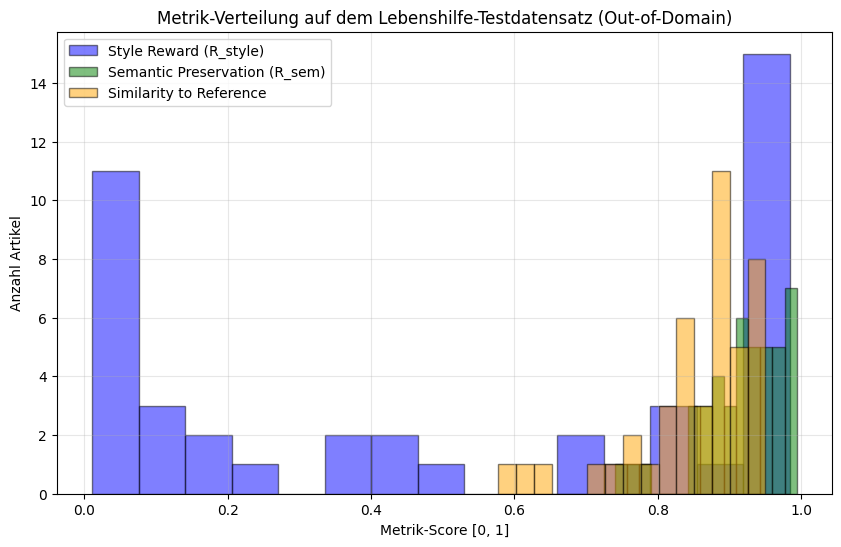

In [30]:
# 4.5 Visualisierung der Metrik-Verteilungen auf dem Lebenshilfe-Set
plt.figure(figsize=(10, 6))
metrics = [
    ("synthetic_simplicity_score", "Style Reward (R_style)", "blue"),
    ("sbert_sim_to_as", "Semantic Preservation (R_sem)", "green"),
    ("sbert_sim_to_ref", "Similarity to Reference", "orange")
]

for col, label, color in metrics:
    plt.hist(lh_eval_df[col], bins=15, alpha=0.5, label=label, color=color, edgecolor="black")

plt.xlabel("Metrik-Score [0, 1]")
plt.ylabel("Anzahl Artikel")
plt.title("Metrik-Verteilung auf dem Lebenshilfe-Testdatensatz (Out-of-Domain)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()